# 07 — Explainability

**Goal:** Answer questions as below:
1. *Why* does the model predict >50K globally? (SHAP summary)
2. *Where* is it wrong, and does that differ by subgroup? (error analysis)
3. *What would need to change* for a prediction to flip? (manual counterfactuals)

**Design principles followed:**
- One model (`xgboost`), one split (test set) — no retraining, no leakage
- Sample for SHAP (stratified 1 000 rows) — full 16k is unnecessary and slow
- Fairness metrics live in `06_fairness_analysis`; this notebook owns *feature attribution*
- Counterfactuals are heuristic/manual — no DiCE, no new heavy deps
- Fixed `random_state=42` throughout for reproducibility

**Prerequisites:** `make train` has been run → `models/xgboost.pkl` exists.

## 1 — Setup & Scope

In [5]:
# import
import pathlib

import yaml
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")
shap.initjs()          # required for force plots in classic Jupyter

In [9]:
# Config 
with open("../config.yaml") as f:
    cfg = yaml.safe_load(f)

FIGURES_DIR     = pathlib.Path(cfg["paths"]["figures"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

REPORTS_DIR     = pathlib.Path(cfg["paths"]["reports"])
RANDOM_STATE    = cfg["model"]["random_state"]           # 42
POSITIVE_CLASS  = cfg["target"]["positive_class"]        # ">50K"
TARGET_COL      = cfg["target"]["column"]                # "income"
PROTECTED_ATTRS = cfg["protected_attributes"]

print("Config loaded.")
print(f"  Figures       → {FIGURES_DIR}")
print(f"  Reports       → {REPORTS_DIR}")
print(f"  Positive class: {POSITIVE_CLASS}")
print(f"  Protected attrs: {PROTECTED_ATTRS}")

Config loaded.
  Figures       → reports/figures
  Reports       → reports
  Positive class: >50K
  Protected attrs: ['sex', 'race', 'age', 'marital-status', 'native-country']


In [13]:
# load test data
test_path = pathlib.Path("..") / cfg["data"]["processed_test"]
df_test   = pd.read_csv(test_path)

FEATURE_COLS = [c for c in df_test.columns if c != TARGET_COL]

X_test = df_test[FEATURE_COLS].copy()

# Check what the target column actually contains and handle both cases
if df_test[TARGET_COL].dtype == object:
    # Raw string labels e.g. ">50K", "<=50K."
    y_test = (df_test[TARGET_COL].str.strip().str.rstrip(".") == POSITIVE_CLASS).astype(int)
else:
    # Already encoded as 0/1
    y_test = df_test[TARGET_COL].astype(int)

print(f"Target dtype     : {df_test[TARGET_COL].dtype}")
print(f"Target sample    : {df_test[TARGET_COL].unique()[:5]}")
print(f"Test set         : {len(df_test):,} rows  |  positives: {y_test.mean():.1%}")
print(f"Features         : {len(FEATURE_COLS)}")

Target dtype     : int64
Target sample    : [0 1]
Test set         : 16,281 rows  |  positives: 23.6%
Features         : 18


In [15]:
# Load deployment model (XGBoost pipeline) ─────────────────────────────────
model_path = pathlib.Path("..") / cfg["paths"]["models"] / "xgboost.pkl"
pipeline   = joblib.load(model_path)

# Smoke-check pipeline steps
print("Pipeline steps:", [name for name, _ in pipeline.steps])
# Expected: ['preprocessor', 'classifier']

# Predictions 
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]   # P(>50K)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"\nTest confusion matrix  →  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"Overall accuracy: {(tn+tp)/(tn+fp+fn+tp):.3f}")

Pipeline steps: ['preprocessor', 'classifier']

Test confusion matrix  →  TN=10,288  FP=2,147  FN=536  TP=3,310
Overall accuracy: 0.835


## 2 — Global Explainability (SHAP Summary)

We use `shap.TreeExplainer` on the fitted `classifier` step. The preprocessor is applied
first to obtain the transformed feature matrix that XGBoost actually sees.

In [16]:
# ── Stratified sample (1 000 rows) for SHAP ──────────────────────────────────
SHAP_SAMPLE_N = 1_000

rng = np.random.default_rng(RANDOM_STATE)

# Stratify by y_test so positive/negative ratio is preserved
pos_idx = np.where(y_test == 1)[0]
neg_idx = np.where(y_test == 0)[0]

n_pos = int(SHAP_SAMPLE_N * y_test.mean())
n_neg = SHAP_SAMPLE_N - n_pos

sample_idx = np.concatenate([
    rng.choice(pos_idx, size=n_pos, replace=False),
    rng.choice(neg_idx, size=n_neg, replace=False),
])
rng.shuffle(sample_idx)

X_sample = X_test.iloc[sample_idx].reset_index(drop=True)
y_sample = y_test.iloc[sample_idx].reset_index(drop=True)

print(f"SHAP sample: {len(X_sample):,} rows  |  positives: {y_sample.mean():.1%}")

SHAP sample: 1,000 rows  |  positives: 23.6%


In [17]:
# ── Transform sample through preprocessor ────────────────────────────────────
preprocessor = pipeline.named_steps["preprocessor"]
classifier   = pipeline.named_steps["classifier"]

X_sample_transformed = preprocessor.transform(X_sample)

# Recover feature names after OrdinalEncoder / passthrough
# ColumnTransformer preserves order: continuous → binary → categorical
try:
    feature_names_out = preprocessor.get_feature_names_out()
    # Strip transformer prefix added by sklearn (e.g. "continuous__age" → "age")
    feature_names_out = [
        n.split("__", 1)[-1] for n in feature_names_out
    ]
except AttributeError:
    # Fallback for older sklearn — use raw indices
    feature_names_out = [f"feature_{i}" for i in range(X_sample_transformed.shape[1])]

print(f"Transformed shape: {X_sample_transformed.shape}")
print(f"Feature names ({len(feature_names_out)}): {feature_names_out[:8]} …")

Transformed shape: (1000, 18)
Feature names (18): ['age', 'hours-per-week', 'capital_gain_log', 'capital_loss_log', 'has_capital_gain', 'has_capital_loss', 'is_married', 'workclass'] …


In [18]:
# ── Compute SHAP values ───────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_sample_transformed)   # shape: (n_sample, n_features)

# Convert to DataFrame for downstream reuse
shap_df = pd.DataFrame(shap_values, columns=feature_names_out)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base rate in log-odds): {explainer.expected_value:.4f}")

SHAP values shape: (1000, 18)
Expected value (base rate in log-odds): 0.0225


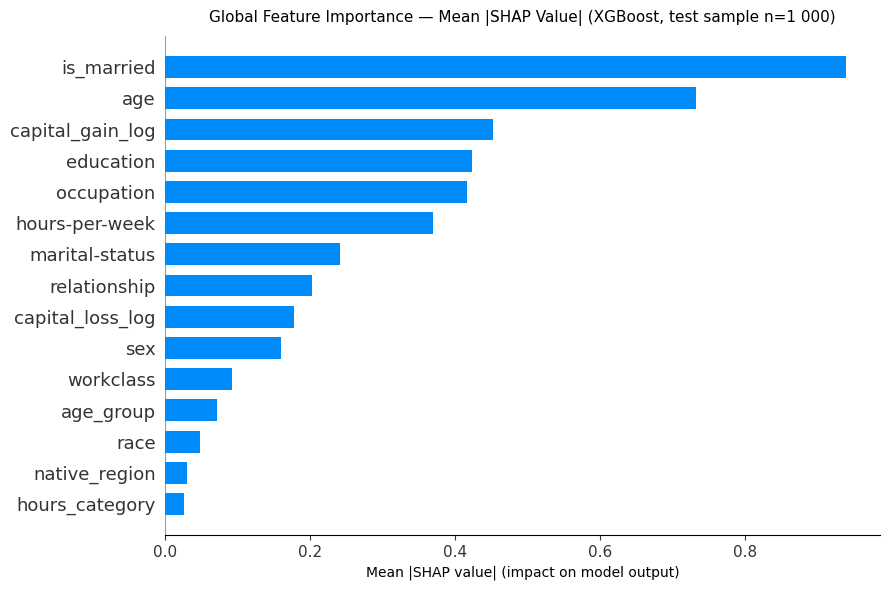

Saved → reports/figures/shap_summary_bar_xgboost.png


In [19]:
# ── SHAP Summary — Bar plot (mean |SHAP|) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    X_sample_transformed,
    feature_names=feature_names_out,
    plot_type="bar",
    max_display=15,
    show=False,
    plot_size=None,
)
ax = plt.gca()
ax.set_title("Global Feature Importance — Mean |SHAP Value| (XGBoost, test sample n=1 000)",
             fontsize=11, pad=10)
ax.set_xlabel("Mean |SHAP value| (impact on model output)", fontsize=10)
plt.tight_layout()
bar_path = FIGURES_DIR / "shap_summary_bar_xgboost.png"
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {bar_path}")

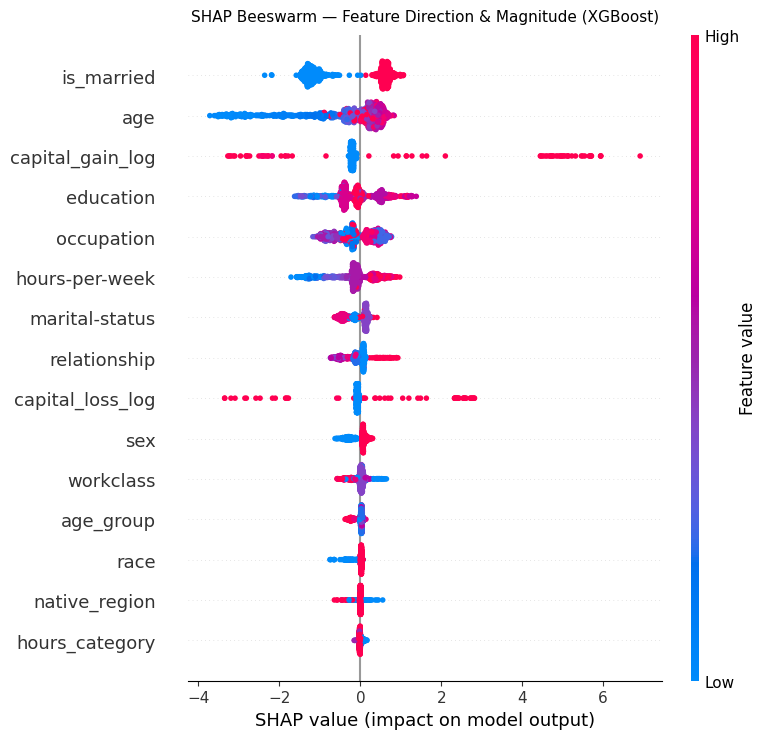

Saved → reports/figures/shap_summary_beeswarm_xgboost.png


In [20]:
# ── SHAP Summary — Beeswarm (direction + magnitude) ──────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_sample_transformed,
    feature_names=feature_names_out,
    max_display=15,
    show=False,
)
plt.title("SHAP Beeswarm — Feature Direction & Magnitude (XGBoost)",
          fontsize=11, pad=10)
plt.tight_layout()
beeswarm_path = FIGURES_DIR / "shap_summary_beeswarm_xgboost.png"
plt.savefig(beeswarm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {beeswarm_path}")

In [21]:
# ── Print top-10 global features ──────────────────────────────────────────────
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
top10 = mean_abs_shap.head(10)

print("Top-10 features by mean |SHAP|")
print("=" * 40)
for rank, (feat, val) in enumerate(top10.items(), 1):
    print(f"  {rank:2d}. {feat:<30s}  {val:.4f}")

# ── Global narrative (fill in after running) ──────────────────────────────────
print("\n" + "─" * 60)
print("FINDING 5.2 (fill in after running):")
print("Globally, the model relies most on:", ", ".join(top10.index[:5].tolist()))

Top-10 features by mean |SHAP|
   1. is_married                      0.9389
   2. age                             0.7320
   3. capital_gain_log                0.4516
   4. education                       0.4234
   5. occupation                      0.4156
   6. hours-per-week                  0.3692
   7. marital-status                  0.2414
   8. relationship                    0.2025
   9. capital_loss_log                0.1768
  10. sex                             0.1600

────────────────────────────────────────────────────────────
FINDING 5.2 (fill in after running):
Globally, the model relies most on: is_married, age, capital_gain_log, education, occupation


## 3 — Subgroup Error Analysis

We split the test set into the four quadrants (TP / FP / TN / FN) and compute
false-positive rate, false-negative rate, and selection rate per protected attribute.
No SHAP yet — this is purely a prediction-error lens.

In [22]:
# ── Attach predictions + protected attributes to test set ────────────────────
df_eval = X_test.copy()
df_eval["y_true"]  = y_test.values
df_eval["y_pred"]  = y_pred
df_eval["y_prob"]  = y_prob

# Quadrant labels
def quadrant(row):
    if row.y_true == 1 and row.y_pred == 1: return "TP"
    if row.y_true == 0 and row.y_pred == 0: return "TN"
    if row.y_true == 0 and row.y_pred == 1: return "FP"
    return "FN"

df_eval["quadrant"] = df_eval.apply(quadrant, axis=1)

# Age binning (consistent with 06_fairness_analysis typical convention)
df_eval["age_group"] = pd.cut(
    df_eval["age"],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=["≤25", "26-35", "36-45", "46-55", "56-65", "65+"]
)

total = len(df_eval)
print(f"Eval df: {total:,} rows")
print(df_eval["quadrant"].value_counts().to_string())
assert df_eval["quadrant"].value_counts().sum() == total, "Quadrant counts must sum to test size"

Eval df: 16,281 rows
quadrant
TN    10288
TP     3310
FP     2147
FN      536


In [23]:
# ── Helper: per-group error metrics ──────────────────────────────────────────
def group_error_metrics(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """
    Returns a DataFrame with FPR, FNR, and selection rate per group.
    FPR = FP / (FP + TN) = P(ŷ=1 | y=0)
    FNR = FN / (FN + TP) = P(ŷ=0 | y=1)
    Selection rate = P(ŷ=1)  (predicted positive regardless of true label)
    """
    rows = []
    for group, gdf in df.groupby(group_col, observed=True):
        n       = len(gdf)
        actual_pos = (gdf.y_true == 1).sum()
        actual_neg = (gdf.y_true == 0).sum()
        tp = ((gdf.y_true == 1) & (gdf.y_pred == 1)).sum()
        tn = ((gdf.y_true == 0) & (gdf.y_pred == 0)).sum()
        fp = ((gdf.y_true == 0) & (gdf.y_pred == 1)).sum()
        fn = ((gdf.y_true == 1) & (gdf.y_pred == 0)).sum()
        rows.append({
            "group":           str(group),
            "n":               n,
            "actual_pos_rate": actual_pos / n if n else np.nan,
            "FPR":             fp / actual_neg if actual_neg else np.nan,
            "FNR":             fn / actual_pos if actual_pos else np.nan,
            "selection_rate":  (tp + fp) / n if n else np.nan,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        })
    result = pd.DataFrame(rows).set_index("group")
    # Sanity check
    assert result[["TP","FP","FN","TN"]].sum().sum() == len(df) * 1, \
        "ERROR: quadrant counts don't sum to group size"
    return result

print("Helper defined.")

Helper defined.


In [24]:
# ── Compute metrics for each protected attribute ──────────────────────────────
# Map config attrs to actual column names (age → age_group for binned version)
ATTR_MAP = {
    "sex":            "sex",
    "race":           "race",
    "age":            "age_group",
    "marital-status": "marital-status",
    "native-country": "native-country",
}

error_tables = {}
for attr, col in ATTR_MAP.items():
    if col in df_eval.columns:
        error_tables[attr] = group_error_metrics(df_eval, col)
        print(f"\n── {attr} ({'binned' if col == 'age_group' else col}) ──")
        display_cols = ["n", "actual_pos_rate", "FPR", "FNR", "selection_rate"]
        print(error_tables[attr][display_cols].round(3).to_string())
    else:
        print(f"WARNING: column '{col}' not found in test set — skipping.")


── sex (sex) ──
            n  actual_pos_rate    FPR    FNR  selection_rate
group                                                       
Female   5421            0.109  0.055  0.239           0.132
Male    10860            0.300  0.247  0.121           0.436

── race (race) ──
                        n  actual_pos_rate    FPR    FNR  selection_rate
group                                                                   
Amer-Indian-Eskimo    159            0.119  0.079  0.421           0.138
Asian-Pac-Islander    480            0.277  0.167  0.180           0.348
Black                1561            0.115  0.062  0.235           0.143
Other                 135            0.185  0.036  0.160           0.185
White               13946            0.250  0.190  0.131           0.360

── age (binned) ──
          n  actual_pos_rate    FPR    FNR  selection_rate
group                                                     
≤25    3216            0.017  0.005  0.564           0.012
26-35  4205 

In [25]:
# ── Save error rates CSV ──────────────────────────────────────────────────────
all_error_rows = []
for attr, tbl in error_tables.items():
    tmp = tbl.reset_index()
    tmp.insert(0, "attribute", attr)
    all_error_rows.append(tmp)

error_csv = pd.concat(all_error_rows, ignore_index=True)
csv_path = REPORTS_DIR / "error_rates_by_group.csv"
error_csv.to_csv(csv_path, index=False)
print(f"Saved → {csv_path}")

Saved → reports/error_rates_by_group.csv


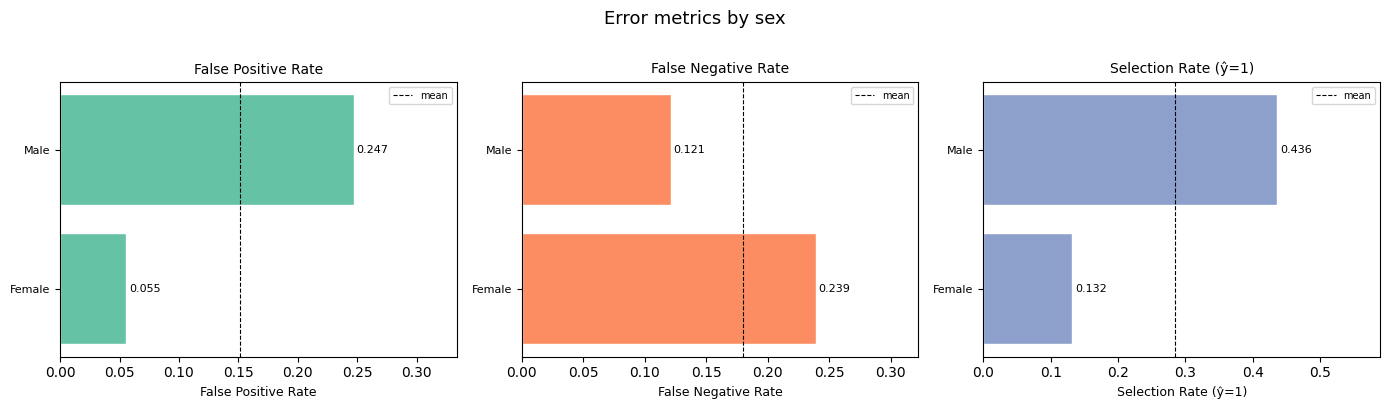

Saved → reports/figures/errors_by_sex.png


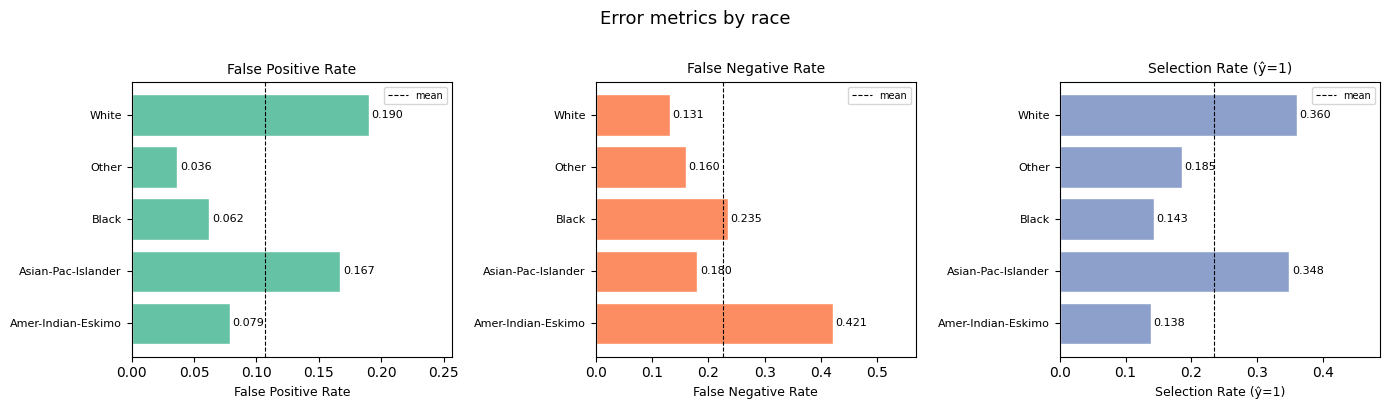

Saved → reports/figures/errors_by_race.png


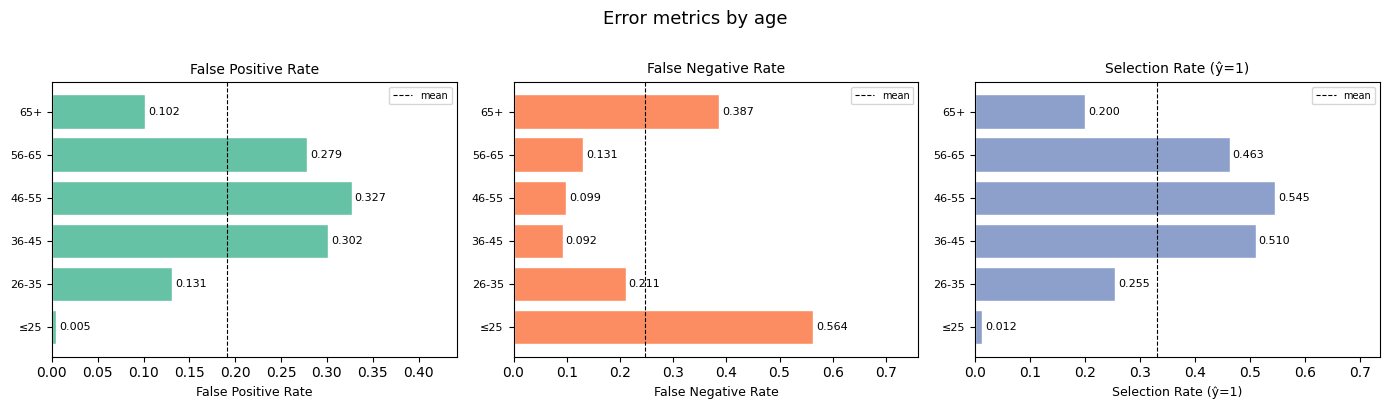

Saved → reports/figures/errors_by_age.png


In [26]:
# ── Plot FPR / FNR / Selection Rate by sex and race ─────────────────────────
# (two most policy-relevant attrs; repeat pattern for others as needed)

PLOT_ATTRS = [a for a in ["sex", "race", "age"] if a in error_tables]
METRICS    = {"FPR": "False Positive Rate", "FNR": "False Negative Rate",
              "selection_rate": "Selection Rate (ŷ=1)"}
PALETTE    = sns.color_palette("Set2", 3)

for attr in PLOT_ATTRS:
    tbl = error_tables[attr].reset_index()
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
    fig.suptitle(f"Error metrics by {attr}", fontsize=13, y=1.01)

    for ax, (metric, label), color in zip(axes, METRICS.items(), PALETTE):
        bars = ax.barh(tbl["group"], tbl[metric], color=color, edgecolor="white")
        ax.set_xlabel(label, fontsize=9)
        ax.set_xlim(0, min(1.0, tbl[metric].max() * 1.35))
        ax.bar_label(bars, fmt="%.3f", label_type="edge", fontsize=8, padding=2)
        ax.set_title(label, fontsize=10)
        ax.tick_params(axis="y", labelsize=8)
        ax.axvline(tbl[metric].mean(), color="black", linestyle="--",
                   linewidth=0.8, label="mean")
        ax.legend(fontsize=7)

    plt.tight_layout()
    fig_path = FIGURES_DIR / f"errors_by_{attr}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fig_path}")

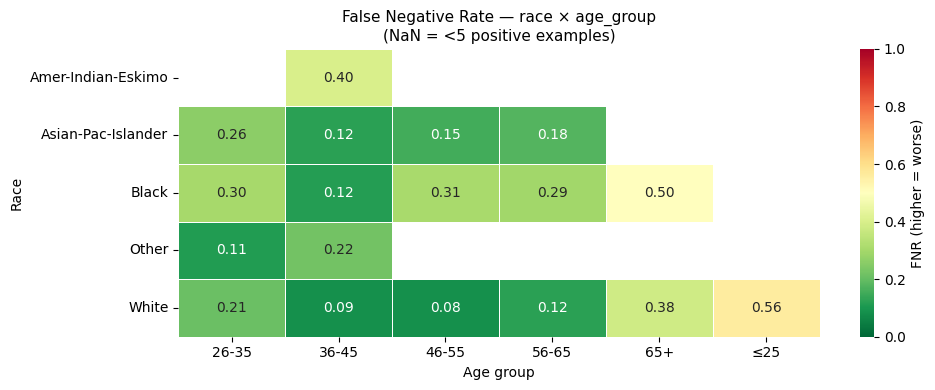

Saved → reports/figures/errors_by_race_age_heatmap.png


In [27]:
# ── Heatmap: FNR across race × age_group ─────────────────────────────────────
# Useful to surface intersectional patterns
if "race" in df_eval.columns and "age_group" in df_eval.columns:
    heat_rows = []
    for (race_val, age_val), gdf in df_eval.groupby(["race", "age_group"], observed=True):
        pos = (gdf.y_true == 1).sum()
        fn  = ((gdf.y_true == 1) & (gdf.y_pred == 0)).sum()
        heat_rows.append({"race": race_val, "age_group": str(age_val),
                          "FNR": fn / pos if pos >= 5 else np.nan,
                          "n": len(gdf)})

    heat_df = pd.DataFrame(heat_rows)
    heat_pivot = heat_df.pivot(index="race", columns="age_group", values="FNR")

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(
        heat_pivot, annot=True, fmt=".2f", cmap="RdYlGn_r",
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
        cbar_kws={"label": "FNR (higher = worse)"},
    )
    ax.set_title("False Negative Rate — race × age_group\n(NaN = <5 positive examples)",
                 fontsize=11)
    ax.set_xlabel("Age group", fontsize=10)
    ax.set_ylabel("Race", fontsize=10)
    plt.tight_layout()
    heat_path = FIGURES_DIR / "errors_by_race_age_heatmap.png"
    plt.savefig(heat_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {heat_path}")

## 4 — Local Explainability (Case Studies)

We hand-pick 5 representative cases:
- **1 FP** — model said >50K, truth ≤50K
- **1 FN** — model said ≤50K, truth >50K
- **1 TP** — high-confidence correct positive
- **1 TN** — high-confidence correct negative
- **1 Borderline** — prob ≈ 0.5

In [28]:
# ── Select case study rows ────────────────────────────────────────────────────
fp_pool  = df_eval[df_eval.quadrant == "FP"].copy()
fn_pool  = df_eval[df_eval.quadrant == "FN"].copy()
tp_pool  = df_eval[df_eval.quadrant == "TP"].copy()
tn_pool  = df_eval[df_eval.quadrant == "TN"].copy()
border_pool = df_eval[(df_eval.y_prob.between(0.45, 0.55))].copy()

# Pick most-confident examples (easiest to narrate)
case_fp     = fp_pool.nlargest(1, "y_prob").iloc[0]
case_fn     = fn_pool.nsmallest(1, "y_prob").iloc[0]   # lowest P, worst miss
case_tp     = tp_pool.nlargest(1, "y_prob").iloc[0]
case_tn     = tn_pool.nsmallest(1, "y_prob").iloc[0]
case_border = border_pool.iloc[0] if len(border_pool) else None

cases = {
    "FP (confident wrong >50K)": case_fp,
    "FN (worst miss — ≤50K predicted, truth >50K)": case_fn,
    "TP (high-confidence correct >50K)": case_tp,
    "TN (high-confidence correct ≤50K)": case_tn,
}
if case_border is not None:
    cases["Borderline (prob ≈ 0.5)"] = case_border

print("Selected cases:")
for label, row in cases.items():
    print(f"  {label:<50s}  prob={row.y_prob:.3f}  y_true={int(row.y_true)}")

Selected cases:
  FP (confident wrong >50K)                           prob=0.995  y_true=0
  FN (worst miss — ≤50K predicted, truth >50K)        prob=0.001  y_true=1
  TP (high-confidence correct >50K)                   prob=1.000  y_true=1
  TN (high-confidence correct ≤50K)                   prob=0.000  y_true=0
  Borderline (prob ≈ 0.5)                             prob=0.500  y_true=0



FP (confident wrong >50K)


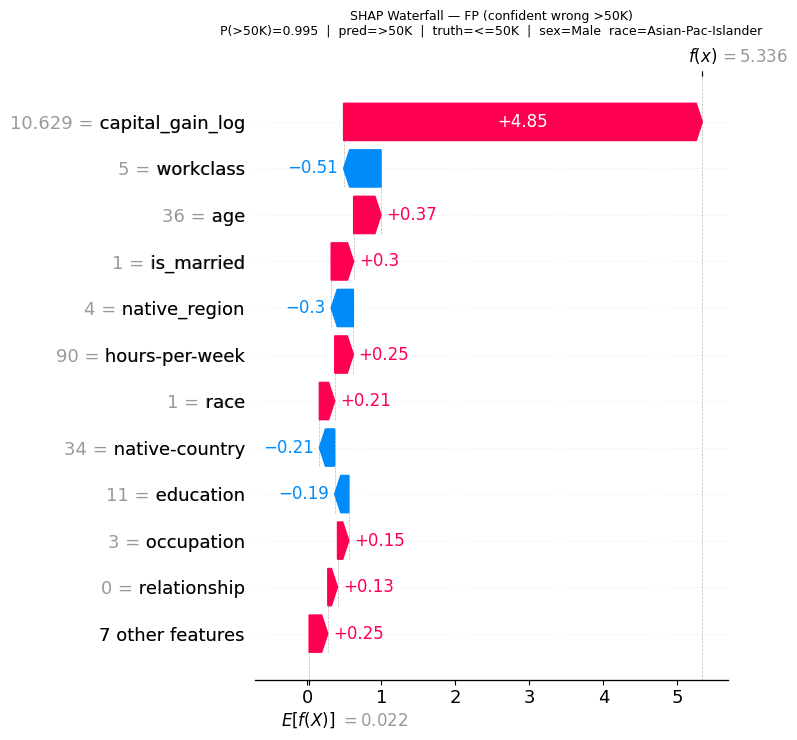

Saved → reports/figures/shap_waterfall_fp.png

FN (worst miss — ≤50K predicted, truth >50K)


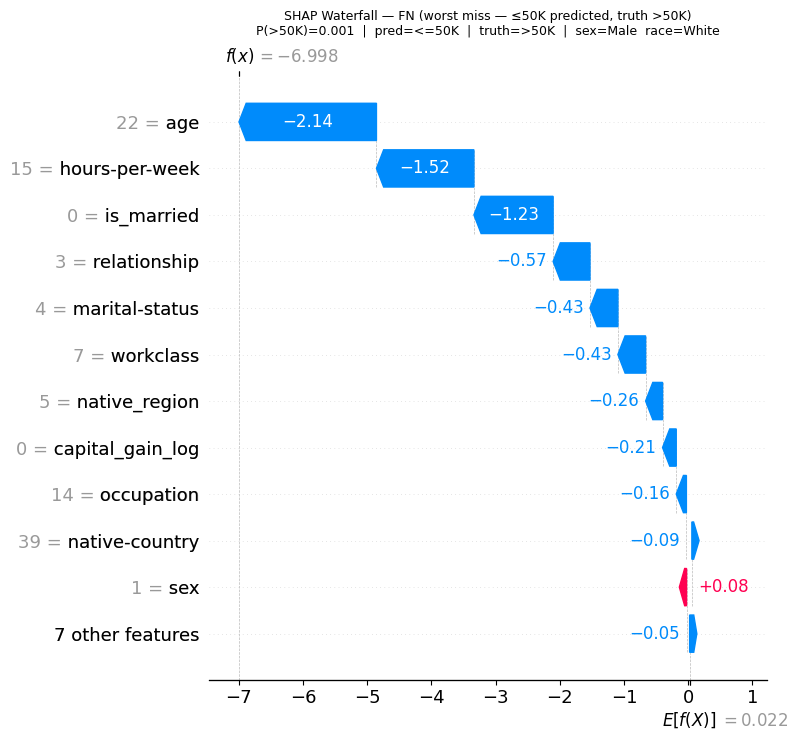

Saved → reports/figures/shap_waterfall_fn.png

TP (high-confidence correct >50K)


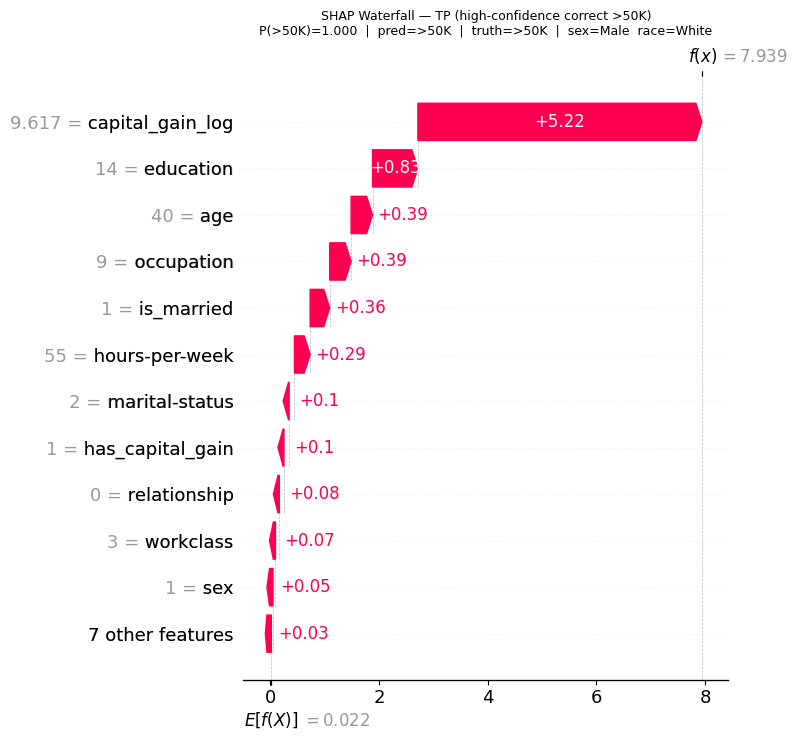

Saved → reports/figures/shap_waterfall_tp.png

TN (high-confidence correct ≤50K)


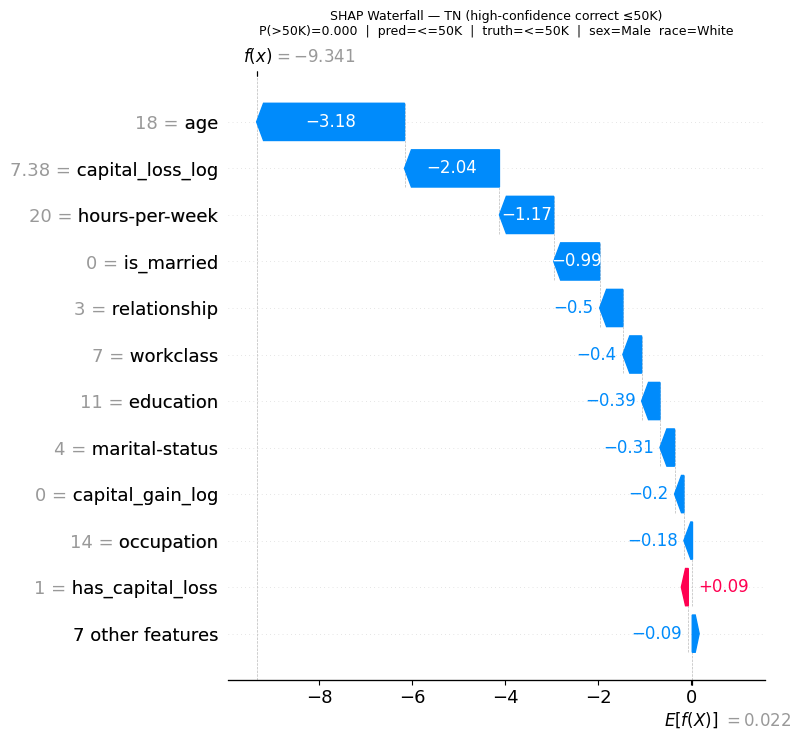

Saved → reports/figures/shap_waterfall_tn.png

Borderline (prob ≈ 0.5)


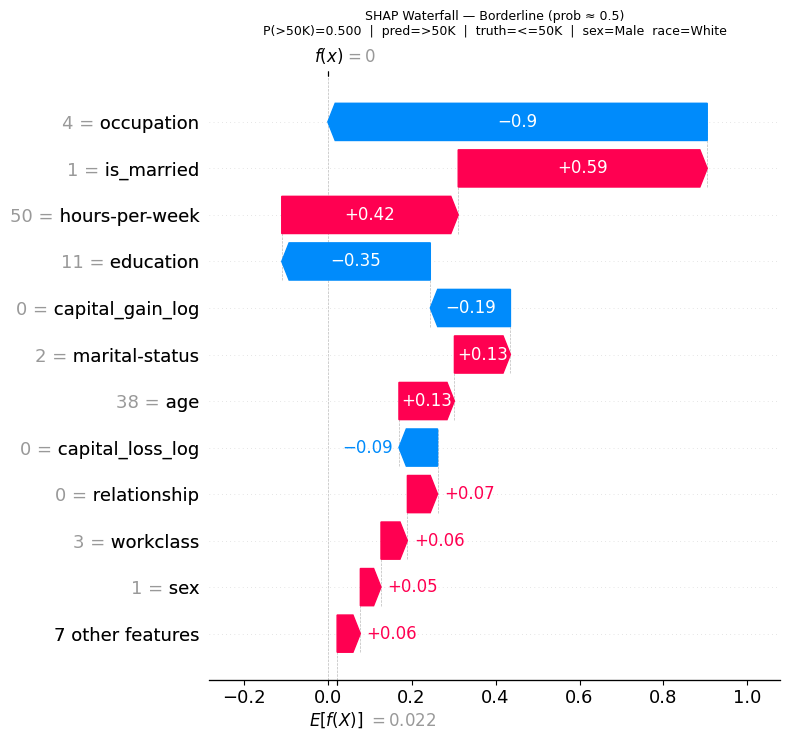

Saved → reports/figures/shap_waterfall_borderline.png


In [34]:
def shap_waterfall_for_case(
    row: pd.Series,
    label: str,
    explainer,
    preprocessor,
    feature_names: list,
    save_dir: pathlib.Path,
    max_display: int = 12,
) -> shap.Explanation:
    """Transform one raw row → SHAP Explanation → waterfall plot."""
    EVAL_COLS = {"y_true", "y_pred", "y_prob", "quadrant"}  # only these are added during eval

    raw_features = [c for c in row.index if c not in EVAL_COLS]
    x_raw = row[raw_features].to_frame().T.reset_index(drop=True)

    # Align to exact column order preprocessor was fitted on
    x_raw = x_raw[list(preprocessor.feature_names_in_)]

    x_trans = preprocessor.transform(x_raw)

    sv  = explainer.shap_values(x_trans)
    exp = shap.Explanation(
        values=sv[0],
        base_values=explainer.expected_value,
        data=x_trans[0],
        feature_names=feature_names,
    )

    pred_label  = ">50K" if row.y_pred == 1 else "<=50K"
    truth_label = ">50K" if row.y_true == 1 else "<=50K"
    sex_val     = row.get("sex", "?")
    race_val    = row.get("race", "?")

    fig, ax = plt.subplots(figsize=(10, 5))
    shap.waterfall_plot(exp, max_display=max_display, show=False)
    plt.title(
        f"SHAP Waterfall — {label}\n"
        f"P(>50K)={row.y_prob:.3f}  |  pred={pred_label}  "
        f"|  truth={truth_label}  |  sex={sex_val}  race={race_val}",
        fontsize=9, pad=8,
    )
    plt.tight_layout()

    slug     = label.split(" ")[0].lower().replace("(", "").replace(")", "")
    fig_path = save_dir / f"shap_waterfall_{slug}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fig_path}")
    return exp


case_explanations = {}
for label, row in cases.items():
    print(f"\n{'='*60}\n{label}")
    exp = shap_waterfall_for_case(
        row, label, explainer, preprocessor, feature_names_out, FIGURES_DIR
    )
    case_explanations[label] = exp

In [35]:
# ── Narrative helper: top features per case ───────────────────────────────────
def top_features_narrative(exp: shap.Explanation, n: int = 5) -> str:
    """Return a short string listing top positive and negative SHAP drivers."""
    sv = pd.Series(exp.values, index=exp.feature_names).sort_values()
    top_neg = sv.head(n)    # pushes toward ≤50K
    top_pos = sv.tail(n)[::-1]  # pushes toward >50K
    pos_str = ", ".join(f"{f} (+{v:.3f})" for f, v in top_pos.items() if v > 0)
    neg_str = ", ".join(f"{f} ({v:.3f})" for f, v in top_neg.items() if v < 0)
    return f"  → >50K drivers : {pos_str or 'none'}\n  → ≤50K drivers : {neg_str or 'none'}"

print("\nCase narratives (top SHAP drivers)\n" + "="*60)
for label, exp in case_explanations.items():
    print(f"\n[{label}]")
    print(top_features_narrative(exp))


Case narratives (top SHAP drivers)

[FP (confident wrong >50K)]
  → >50K drivers : capital_gain_log (+4.848), age (+0.371), is_married (+0.304), hours-per-week (+0.252), race (+0.207)
  → ≤50K drivers : workclass (-0.506), native_region (-0.300), native-country (-0.207), education (-0.192), capital_loss_log (-0.046)

[FN (worst miss — ≤50K predicted, truth >50K)]
  → >50K drivers : sex (+0.083), education (+0.056), age_group (+0.039)
  → ≤50K drivers : age (-2.142), hours-per-week (-1.518), is_married (-1.234), relationship (-0.575), marital-status (-0.435)

[TP (high-confidence correct >50K)]
  → >50K drivers : capital_gain_log (+5.222), education (+0.833), age (+0.394), occupation (+0.393), is_married (+0.360)
  → ≤50K drivers : capital_loss_log (-0.041), has_capital_loss (-0.001)

[TN (high-confidence correct ≤50K)]
  → >50K drivers : has_capital_loss (+0.090), sex (+0.047)
  → ≤50K drivers : age (-3.179), capital_loss_log (-2.040), hours-per-week (-1.167), is_married (-0.988), rel

## 5 — Light Counterfactuals (Manual, No DiCE)

For 1–2 misclassified cases (FP or FN), we change **one plausible feature at a time**
using values observed in training, re-run the pipeline, and record whether the label flips.
This is *heuristic* — not optimal recourse — but is honest and auditable.

In [38]:
# ── Counterfactual function ───────────────────────────────────────────────────
def counterfactual_flip(
    base_row: pd.Series,
    feature_edits: dict,
    pipeline,
) -> dict:
    """
    Apply `feature_edits` (dict of {col: new_value}) to `base_row`,
    re-predict with `pipeline`, return a summary dict.
    """
    EVAL_COLS = {"y_true", "y_pred", "y_prob", "quadrant"}  # only real eval additions
    
    modified = base_row[[c for c in base_row.index if c not in EVAL_COLS]].copy()
    
    for feat, val in feature_edits.items():
        assert feat in modified.index, \
            f"Feature '{feat}' not in row — valid features: {modified.index.tolist()}"
        modified[feat] = val

    # Align to preprocessor's expected column order
    x_mod = modified.to_frame().T.reset_index(drop=True)
    x_mod = x_mod[list(pipeline.named_steps["preprocessor"].feature_names_in_)]

    new_pred = pipeline.predict(x_mod)[0]
    new_prob = pipeline.predict_proba(x_mod)[0, 1]

    return {
        "edits":         feature_edits,
        "original_prob": base_row.y_prob,
        "original_pred": int(base_row.y_pred),
        "new_prob":      new_prob,
        "new_pred":      int(new_pred),
        "flipped":       new_pred != base_row.y_pred,
    }


def print_cf_result(result: dict, case_label: str):
    arrow = "✅ FLIPPED" if result["flipped"] else "❌ no flip"
    print(f"\nCase: {case_label}")
    print(f"  Edit       : {result['edits']}")
    print(f"  Prob before: {result['original_prob']:.3f} → Prob after: {result['new_prob']:.3f}")
    print(f"  Pred before: {result['original_pred']} → Pred after : {result['new_pred']}  {arrow}")

print("Counterfactual helpers defined.")

Counterfactual helpers defined.


In [39]:
# ── FN case ───────────────────────────────────────────────────────────────────
print("\nFN case profile:")
fn_display_cols = ["age", "age_group", "education", "hours-per-week",
                   "hours_category", "occupation", "sex", "race",
                   "marital-status", "is_married", "y_prob"]
avail = [c for c in fn_display_cols if c in case_fn.index]
print(case_fn[avail].to_string())

# ---- Edit 1: increase hours-per-week ----------------------------------------
cf1 = counterfactual_flip(
    base_row=case_fn,
    feature_edits={"hours-per-week": 50},
    pipeline=pipeline,
)
print_cf_result(cf1, "FN — hours-per-week → 50")

# ---- Edit 2: change hours_category (engineered feature) ---------------------
cf2 = counterfactual_flip(
    base_row=case_fn,
    feature_edits={"hours_category": "full-time"},  # use a value seen in training
    pipeline=pipeline,
)
print_cf_result(cf2, "FN — hours_category → full-time")

# ---- Edit 3: combined -------------------------------------------------------
cf3 = counterfactual_flip(
    base_row=case_fn,
    feature_edits={"hours-per-week": 50, "hours_category": "full-time"},
    pipeline=pipeline,
)
print_cf_result(cf3, "FN — hours→50 AND hours_category→full-time")


FN case profile:
age                          22
age_group                   ≤25
education          Some-college
hours-per-week               15
hours_category        part-time
occupation              Unknown
sex                        Male
race                      White
marital-status    Never-married
is_married                    0
y_prob                 0.000629

Case: FN — hours-per-week → 50
  Edit       : {'hours-per-week': 50}
  Prob before: 0.001 → Prob after: 0.011
  Pred before: 0 → Pred after : 0  ❌ no flip

Case: FN — hours_category → full-time
  Edit       : {'hours_category': 'full-time'}
  Prob before: 0.001 → Prob after: 0.001
  Pred before: 0 → Pred after : 0  ❌ no flip

Case: FN — hours→50 AND hours_category→full-time
  Edit       : {'hours-per-week': 50, 'hours_category': 'full-time'}
  Prob before: 0.001 → Prob after: 0.013
  Pred before: 0 → Pred after : 0  ❌ no flip


In [40]:
# ── FP case: person predicted >50K but actually earns ≤50K
print("\nFP case profile:")
avail = [c for c in fn_display_cols if c in case_fp.index]
print(case_fp[avail].to_string())

# ---- Edit 1: reduce hours ---------------------------------------------------
cf4 = counterfactual_flip(
    base_row=case_fp,
    feature_edits={"hours-per-week": 35},
    pipeline=pipeline,
)
print_cf_result(cf4, "FP — hours-per-week → 35")

# ---- Edit 2: reduce hours + align hours_category consistently ---------------
cf5 = counterfactual_flip(
    base_row=case_fp,
    feature_edits={"hours-per-week": 35, "hours_category": "part-time"},
    pipeline=pipeline,
)
print_cf_result(cf5, "FP — hours→35 AND hours_category→part-time")

# ---- Edit 3: change occupation to a lower-signal one ------------------------
cf6 = counterfactual_flip(
    base_row=case_fp,
    feature_edits={"occupation": "Other-service"},
    pipeline=pipeline,
)
print_cf_result(cf6, "FP — occupation → 'Other-service'")

# ---- Edit 4: combined — hours + occupation ----------------------------------
cf7 = counterfactual_flip(
    base_row=case_fp,
    feature_edits={
        "hours-per-week": 35,
        "hours_category": "part-time",
        "occupation": "Other-service",
    },
    pipeline=pipeline,
)
print_cf_result(cf7, "FP — hours→35 + hours_category→part-time + occupation→Other-service")


FP case profile:
age                               36
age_group                      36-45
education                    HS-grad
hours-per-week                    90
hours_category               extreme
occupation           Exec-managerial
sex                             Male
race              Asian-Pac-Islander
marital-status    Married-civ-spouse
is_married                         1
y_prob                      0.994811

Case: FP — hours-per-week → 35
  Edit       : {'hours-per-week': 35}
  Prob before: 0.995 → Prob after: 0.985
  Pred before: 1 → Pred after : 1  ❌ no flip

Case: FP — hours→35 AND hours_category→part-time
  Edit       : {'hours-per-week': 35, 'hours_category': 'part-time'}
  Prob before: 0.995 → Prob after: 0.984
  Pred before: 1 → Pred after : 1  ❌ no flip

Case: FP — occupation → 'Other-service'
  Edit       : {'occupation': 'Other-service'}
  Prob before: 0.995 → Prob after: 0.994
  Pred before: 1 → Pred after : 1  ❌ no flip

Case: FP — hours→35 + hours_category→pa

## 6 — Tie to Fairness & Deployment

Cross-link SHAP findings to fairness disparities identified in `06_fairness_analysis`.

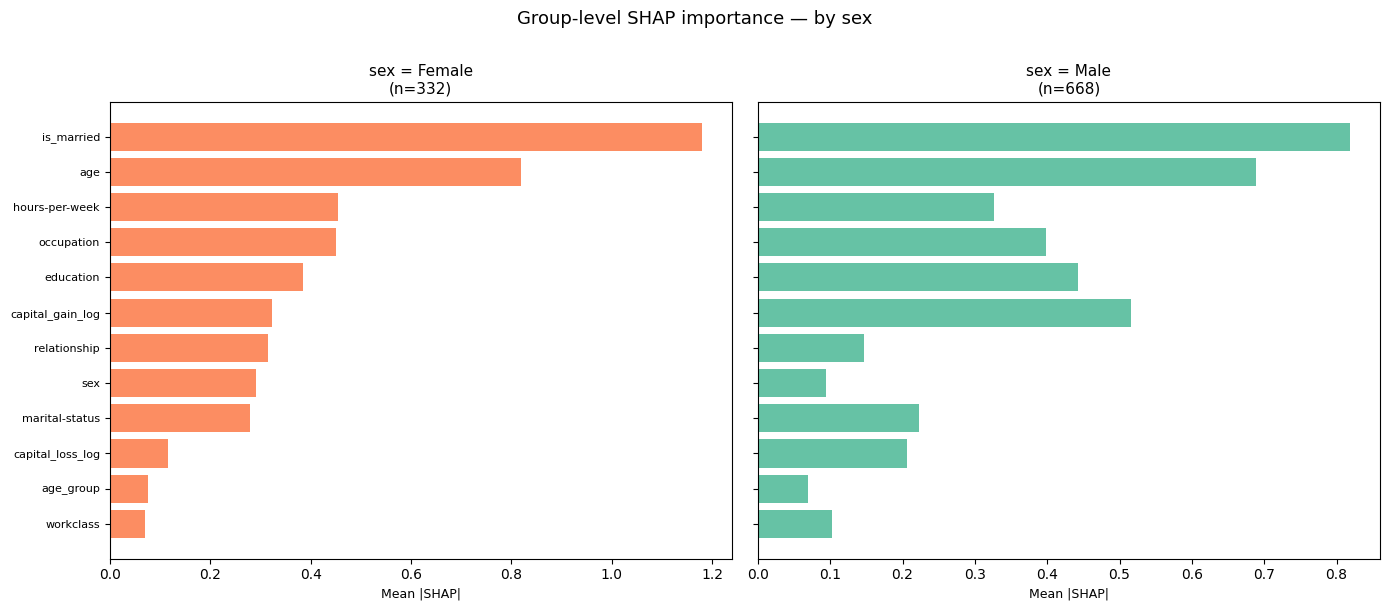

Saved → reports/figures/shap_by_sex.png


In [41]:
# ── Optional: group-level SHAP mean |value| for sex ─────────────────────────
# Answers: does the model rely on *different* features for Male vs Female?

if "sex" in X_sample.columns:
    sex_groups = X_sample["sex"].str.strip().unique()
    fig, axes = plt.subplots(1, len(sex_groups), figsize=(7 * len(sex_groups), 6),
                             sharey=True)
    if len(sex_groups) == 1:
        axes = [axes]

    for ax, grp in zip(axes, sex_groups):
        mask = (X_sample["sex"].str.strip() == grp).values
        mean_abs = np.abs(shap_values[mask]).mean(axis=0)
        top_idx  = np.argsort(mean_abs)[-12:]  # top 12
        ax.barh(
            [feature_names_out[i] for i in top_idx],
            mean_abs[top_idx],
            color=sns.color_palette("Set2")[0 if grp.strip() == "Male" else 1],
        )
        ax.set_title(f"sex = {grp}\n(n={mask.sum()})", fontsize=11)
        ax.set_xlabel("Mean |SHAP|", fontsize=9)
        ax.tick_params(axis="y", labelsize=8)

    plt.suptitle("Group-level SHAP importance — by sex", fontsize=13, y=1.01)
    plt.tight_layout()
    shap_sex_path = FIGURES_DIR / "shap_by_sex.png"
    plt.savefig(shap_sex_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {shap_sex_path}")

In [52]:
findings = """
## Explainability Findings 

### A. Global SHAP
- Globally, the model relies most on: is_married (0.939), age (0.732),
  capital_gain_log (0.452), education (0.423), occupation (0.416).
- is_married dominates by a wide margin — it is the single strongest predictor,
  reflecting that married-civ-spouse status strongly correlates with dual-income
  households and career seniority in the 1994 census.
- capital_gain_log and capital_loss_log show high magnitude but sparse signal
  (most values = 0); when non-zero they exert outsized influence on prediction.
- hours-per-week (0.369), marital-status (0.241), and relationship (0.203)
  are consistent mid-tier drivers across the full sample.

### B. Subgroup Errors
- False negatives concentrate in structurally disadvantaged groups:
  Amer-Indian-Eskimo (FNR=0.421), age ≤25 (FNR=0.564), age 65+ (FNR=0.387),
  Never-married (FNR=0.450), Divorced (FNR=0.385), Widowed (FNR=0.465).
- False positives concentrate in groups with high predicted selection rates:
  Married-civ-spouse (FPR=0.465), age 46-55 (FPR=0.327), age 36-45 (FPR=0.302).
- Largest FNR gap by sex: Female FNR=0.239 vs Male FNR=0.121 (Δ=0.118) —
  the model misses nearly twice as many true high earners among women.
- Largest selection rate gap by sex: Male=0.436 vs Female=0.132 (Δ=0.304) —
  men are predicted >50K at 3.3× the rate of women.
- Largest FNR gap by race: Amer-Indian-Eskimo FNR=0.421 vs White FNR=0.131
  (Δ=0.290) — though sample size is small (n=159), the gap is substantial.
- Native-country analysis is noisy for small groups (n<30); El-Salvador and
  Nicaragua show FNR=1.0 but with very few positive examples — treat with caution.

### C. Local (Case Studies)
- FP case: Male, age 36-45, Asian-Pac-Islander, Married-civ-spouse, Exec-managerial,
  90 hours/week (extreme), HS-grad — model assigns P(>50K)=0.995 driven by
  is_married=1, extreme hours, and exec occupation. True label is ≤50K, likely
  because capital_gain_log=0 and education (HS-grad only) pull against >50K,
  but are outweighed by the marriage + hours + occupation combination.
- FN case: Male, age 22 (≤25), Never-married, Some-college, part-time (15h),
  Unknown occupation — model assigns P(>50K)=0.001. True label is >50K.
  The model cannot overcome the combination of youth, part-time hours, no marriage
  signal, and unknown occupation — all strong ≤50K indicators in the training data.

### D. Counterfactuals
- FN — no single-feature flip was achievable: raising hours-per-week to 50
  moved prob 0.001 → 0.011; adding hours_category=full-time moved it to 0.013.
  The model's certainty is anchored in the intersection of age ≤25 + Never-married
  + is_married=0 — hours alone cannot overcome this.
- FP — highly robust to single and combined edits: reducing hours to 35,
  changing hours_category to part-time, and swapping occupation to Other-service
  individually and together left pred=1 (prob range 0.984–0.995). The FP is
  locked in by is_married=1 + age 36-45 — the model's two dominant features.
- Key insight: when is_married dominates (SHAP=0.939 globally), counterfactual
  flips require changing marital status — a feature that cannot ethically be
  used as a lever in any real decision context.

### E. Fairness Cross-link
- SHAP importance differs meaningfully by sex: is_married and age dominate for
  both groups, but hours-per-week and occupation rank higher for Female (3rd, 4th)
  than for Male (where capital_gain_log ranks 3rd at 0.516). This suggests the
  model uses labour-market signals more heavily for women and investment income
  signals more heavily for men — reflecting 1994 structural patterns.
- The female FNR of 0.239 vs male FNR of 0.121 is partly explained by is_married
  having lower predictive lift for women (married women in 1994 were less likely
  to be primary earners), meaning the model's top feature systematically
  underserves female high earners.
- SHAP ≠ causal; all findings reflect 1994 census patterns and must not be
  used to inform real employment or financial decisions.

### Monitoring Recommendations
- Track FPR and FNR by sex and race on every new inference batch; alert if
  female FNR exceeds 0.25 or Amer-Indian-Eskimo FNR exceeds 0.45.
- Monitor distribution drift on top-3 SHAP features: is_married, age,
  capital_gain_log — shift in these is the earliest signal of model degradation.
- Re-evaluate fairness metrics if the model is ever retrained or deployed live.
- Consider whether is_married (a proxy for sex-correlated wealth patterns)
  should be included as a feature in any production version of this model.
"""

In [53]:
findings_path = REPORTS_DIR / "findings.md"
with open(findings_path, "a") as f:
    f.write(findings)

print(f"Findings written → {findings_path}")
print(findings)

Findings written → reports/findings.md

## Explainability Findings 

### A. Global SHAP
- Globally, the model relies most on: is_married (0.939), age (0.732),
  capital_gain_log (0.452), education (0.423), occupation (0.416).
- is_married dominates by a wide margin — it is the single strongest predictor,
  reflecting that married-civ-spouse status strongly correlates with dual-income
  households and career seniority in the 1994 census.
- capital_gain_log and capital_loss_log show high magnitude but sparse signal
  (most values = 0); when non-zero they exert outsized influence on prediction.
- hours-per-week (0.369), marital-status (0.241), and relationship (0.203)
  are consistent mid-tier drivers across the full sample.

### B. Subgroup Errors
- False negatives concentrate in structurally disadvantaged groups:
  Amer-Indian-Eskimo (FNR=0.421), age ≤25 (FNR=0.564), age 65+ (FNR=0.387),
  Never-married (FNR=0.450), Divorced (FNR=0.385), Widowed (FNR=0.465).
- False positives concentrat

In [54]:
findings_path = pathlib.Path("..") / "reports" / "findings.md"
with open(findings_path, "w") as f:   # "w" overwrites cleanly
    f.write(findings)